# Trajectory Analysis — Evaluation Metrics, Methodology, and Diagnostics

This notebook collects the conceptual material needed to evaluate any
VO / VIO / LIO / SLAM trajectory: what the metrics actually measure,
why naive comparison against ground truth is misleading, which
alignment to use for which sensor configuration, and the failure
modes (parallax loss, unobservable yaw, tracker drift) that drive
*why* trajectories drift in characteristic ways.

It fuses two perspectives:

* **Zhang & Scaramuzza (IROS 2018)** — the canonical tutorial on
  quantitative VO/VIO trajectory evaluation. Provides the
  unobservable-DoF taxonomy, the sub-trajectory drift methodology,
  and the math for Sim(3) / SE(3) / posyaw / yaw-only alignment.
* **Practical benchmarking notes from the `vio_benchmark` work** —
  what `evo_ape` actually prints, why raw APE on a fresh VIO is
  almost always huge, how parallax-poor motion silently breaks mono
  VIO, and why mono VIO will always disagree with ground truth on
  global yaw without an external heading sensor.

Companion docs:

* [Evaluation metrics for poses and trajectories — how ATE/RPE relate to the Image Matching Challenge AA/mAA scores](../vo_evaluation_metrics.ipynb)
* [Deep-learning monocular VO architectures and losses](vit_monocular_vo.ipynb)
* [Head-to-head VIO comparison on EuRoC](../../vio_benchmark/docs/COMPARISON.md)
* [7-step diagnostic procedure for a broken estimator](../../vio_benchmark/docs/VIO_DIAGNOSTIC_GUIDE.md)
* [Estimator configuration parameter reference](../../vio_benchmark/docs/PARAMETERS.md)
* [Dataset recipes — EuRoC, TUM-VIO, M2DGR, 4Seasons](../../vio_benchmark/docs/DATASETS.md)


## 1. Why naive comparison fails — the alignment problem

A VO/SLAM trajectory is only defined **up to an unobservable gauge transform**. Two systems can be equally accurate in the geometry they recover but live in completely different reference frames.

The set of "free" degrees of freedom depends on the **sensor configuration**:

| System                          | Unobservable DoF                  | Required alignment |
| ------------------------------- | --------------------------------- | ------------------ |
| Monocular VO                    | 7 DoF: 6-DoF pose + **scale**     | **Sim(3)**         |
| Stereo / RGB-D / LiDAR          | 6 DoF: initial pose               | **SE(3)**          |
| Visual-Inertial (VIO)           | 4 DoF: position + **yaw**         | **posyaw**         |
| Gravity-aligned, position observable (e.g. GNSS-aided) | 1 DoF: yaw   | **yaw-only**       |

**Why each row**: gravity (a vertical vector) constrains pitch and roll. Yaw is rotation *around* gravity and carries no IMU-static signal. Monocular vision can recover geometry but not absolute scale. Stereo or depth fixes scale via the known baseline.

Aligning over the **correct** set of unobservable DoFs is critical:

* Using a **stronger** alignment than necessary (e.g., Sim(3) for a VIO system) *artificially* hides real scale drift that the system is supposed to recover — the headline number looks great but the estimator is silently broken.
* Using a **weaker** alignment than necessary (e.g., yaw-only on monocular VO) produces huge errors that have nothing to do with the algorithm's accuracy.

**Rule (Zhang & Scaramuzza):** align over exactly the unobservable DoFs of the system, and nothing more.

### The world-frame mismatch in practice

When you read "VIO RMSE is 0.48 m" in any paper, it's almost never the raw error against ground truth. The reason is structural: `Tgt` is in the dataset's world frame, but `Test` is in whatever frame the estimator chose at init. For OpenVINS that's `global`; for VINS-Fusion it's `world`; for FAST-LIO it's `camera_init`. **These frames are arbitrarily rotated relative to the world** because IMU-only init can't determine yaw (see §10).

A *correct* estimator with a wrong-yawed world frame still gives a huge raw APE — the error is measuring the frame mismatch, not the estimator quality. Alignment strips that out before reporting.


## 2. Absolute Pose Error (APE / ATE)

Given two time-synchronised trajectories:

| | |
|---|---|
| **GT** | $\{T^{gt}(t_1), T^{gt}(t_2), \dots, T^{gt}(t_N)\}$ — each $T^{gt}$ an $SE(3)$ pose at time $t_i$ |
| **Est** | $\{\hat{T}(t_1), \dots, \hat{T}(t_N)\}$ — same timestamps, from VIO/LIO/VO |

### 2.1 Per-sample error

Two equivalent forms — the full $SE(3)$ form, and the position-only shorthand used for the headline number:

$$
E_i^{abs} \;=\; (T_i^{gt})^{-1}\,\hat{T}_i^{aligned}, \qquad
e_i \;=\; \mathbf{p}_i^{gt} - \hat{\mathbf{p}}_i^{aligned} \quad [\text{m}].
$$

Splitting $E_i^{abs}$ into rotation $R_i^{err}$ and translation $\mathbf{t}_i^{err}$:

$$
\mathrm{APE}^{trans}_i = \|\mathbf{t}_i^{err}\|_2 \;\;[\text{m}],\qquad
\mathrm{APE}^{rot}_i = \big|\angle R_i^{err}\big| = \arccos\!\Big(\tfrac{\mathrm{tr}(R_i^{err}) - 1}{2}\Big) \;\;[\text{rad}].
$$

### 2.2 Aggregate statistics

```
APE_RMSE   = √( (1/N) · Σ ‖e_i‖² )
APE_median = median_i ‖e_i‖
APE_max    = max_i ‖e_i‖
APE_mean   = (1/N) · Σ ‖e_i‖
```

`evo_ape` prints all of these.

### 2.3 Strengths and weaknesses

**Strengths** — a single intuitive number; good for assessing **global consistency** (loop closures, drift bounding).

**Weaknesses** — Zhang & Scaramuzza specifically warn:

* **Highly sensitive to where drift happens**: a single large excursion at the end of the trajectory dominates the RMSE.
* **Depends on alignment choice**: switching from SE(3) to Sim(3) can change the number by an order of magnitude on monocular trajectories.
* **Not normalized by path length**: a 1 m APE on a 10 m sequence is awful; on a 10 km sequence it's excellent. APE values across different sequences are not directly comparable.

For these reasons, **never report APE alone** — pair it with sub-trajectory drift (§5).


**Running example** — all code cells below share one tiny scenario: the ground truth is a 20 m × 20 m square loop, and the "estimator" reproduces its shape well but lives in a mis-yawed, mis-scaled world frame and drifts slowly — exactly the situation of §1.

In [1]:
import numpy as np
np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(0)

# Ground truth: 20 m x 20 m square loop, one pose every 0.5 m (z = 0)
side = np.arange(0, 20, 0.5)
gt = np.vstack([
    np.stack([side, np.zeros_like(side)], 1),          # east  (+x)
    np.stack([np.full_like(side, 20.0), side], 1),     # north (+y)
    np.stack([20 - side, np.full_like(side, 20.0)], 1),# west
    np.stack([np.zeros_like(side), 20 - side], 1),     # south
])
gt = np.column_stack([gt, np.zeros(len(gt))])          # (N, 3)
N = len(gt)

# The estimate: correct shape, but its world frame is yawed 30deg (arbitrary
# init yaw, section 10), scaled by 0.9 (mono scale error), offset by (5, -2) m,
# and it drifts ~1 cm per pose on top of mm-level noise.
yaw = np.deg2rad(30.0)
Rz = np.array([[np.cos(yaw), -np.sin(yaw), 0],
               [np.sin(yaw),  np.cos(yaw), 0],
               [0, 0, 1]])
drift = np.outer(np.arange(N), [0.010, 0.005, 0])
est = 0.9 * gt @ Rz.T + np.array([5.0, -2.0, 0]) + drift + rng.normal(0, 0.002, (N, 3))

raw = np.linalg.norm(gt - est, axis=1)                 # raw APE, no alignment
print(f"N = {N} poses, path length = {0.5 * N:.0f} m")
print(f"raw APE RMSE = {np.sqrt(np.mean(raw**2)):.2f} m,  max = {raw.max():.2f} m")
print("-> huge, but it measures the frame mismatch, not the estimator.")

N = 160 poses, path length = 80 m
raw APE RMSE = 5.72 m,  max = 8.17 m
-> huge, but it measures the frame mismatch, not the estimator.


## 3. Relative Pose Error (RPE)

RPE measures **local consistency** over a fixed window $\Delta$ (in time or in distance). Defined per Sturm et al. (TUM RGB-D):

$$
E_i^{rel}(\Delta) \;=\; \Big((T_i^{gt})^{-1}\, T_{i+\Delta}^{gt}\Big)^{-1} \, \Big(\hat{T}_i^{-1}\, \hat{T}_{i+\Delta}\Big).
$$

In words: take the GT relative motion from frame $i \to i{+}\Delta$, the estimated relative motion from frame $i \to i{+}\Delta$, and measure their mismatch.

Translation / rotation statistics are formed the same way as APE:

$$
\mathrm{RPE}^{trans}_{\mathrm{RMSE}}(\Delta) = \sqrt{\tfrac{1}{N-\Delta}\sum_i \big\| \mathbf{t}\big(E_i^{rel}(\Delta)\big) \big\|^2}.
$$

### 3.1 Why RPE is gauge-invariant

Both trajectories are made *relative* to time $t_i$, so the initial-yaw and scale ambiguities cancel out. No global alignment is needed. This is why KITTI's headline benchmark is RPE-based.

For $\Delta = 1$ frame, RPE measures the **inter-frame drift rate**. For large $\Delta$, it approaches APE behavior over that window.

### 3.2 Limitation — the arbitrary choice of $\Delta$

A single $\Delta$ in seconds is hard to compare across sequences with different velocities. The fix is to use **multiple sub-trajectory lengths** — see §5.


In [2]:
# RPE needs no alignment: both motions are made relative to pose i,
# expressed in that pose's own frame, so the 30 deg yaw and the 5 m offset cancel.
def headings(P):
    """Rotation of each pose: x-axis along the direction of travel, z up."""
    d = np.gradient(P, axis=0); d /= np.linalg.norm(d, axis=1, keepdims=True)
    up = np.array([0.0, 0.0, 1.0])
    Rs = np.empty((len(P), 3, 3))
    for i, f in enumerate(d):
        left = np.cross(up, f); left /= np.linalg.norm(left)
        Rs[i] = np.column_stack([f, left, up])
    return Rs

R_gt  = headings(gt)
R_est = np.einsum('ij,njk->nik', Rz, R_gt)     # estimator frame yawed by 30 deg

def rpe_trans(P, RP, Q, RQ, delta):
    errs = np.empty(len(P) - delta)
    for i in range(len(errs)):
        d_gt  = RP[i].T @ (P[i + delta] - P[i])   # GT relative motion
        d_est = RQ[i].T @ (Q[i + delta] - Q[i])   # estimated relative motion
        errs[i] = np.linalg.norm(d_gt - d_est)
    return errs

for delta, label in [(1, "0.5 m"), (20, "10 m")]:
    e = rpe_trans(gt, R_gt, est, R_est, delta)
    print(f"RPE, window {label:>5}: RMSE = {np.sqrt(np.mean(e**2)):.3f} m")

print("\nWhat survives is the *real* error: the 10% mono scale error")
print("(0.05 m per 0.5 m step, 1 m per 10 m window) plus the slow drift.")

RPE, window 0.5 m: RMSE = 0.051 m
RPE, window  10 m: RMSE = 0.970 m

What survives is the *real* error: the 10% mono scale error
(0.05 m per 0.5 m step, 1 m per 10 m window) plus the slow drift.


## 4. Alignment — Umeyama and friends

Alignment finds the closed-form transform $S$ that minimises the position residual:

$$
\sum_i \big\| \mathbf{p}_i^{gt} - S(\hat{\mathbf{p}}_i) \big\|^2 .
$$

The choice of allowable $S$ is dictated by §1's unobservable-DoF table.

### 4.1 Sim(3) — Umeyama (1991), for monocular

For monocular VO, you align with a **similarity transform** $(s, R, \mathbf{t}) \in \mathrm{Sim}(3)$:

$$
(s^\star, R^\star, \mathbf{t}^\star) \;=\; \arg\min_{s, R, \mathbf{t}}\; \sum_{i=1}^{N}\, \big\| \, s\,R\,\hat{\mathbf{p}}_i + \mathbf{t} \;-\; \mathbf{p}_i^{gt}\,\big\|_2^{2}
$$

**Umeyama's closed form**:

1. Compute centroids $\bar{\mathbf{p}}, \bar{\mathbf{q}}$ and centered points.
2. Cross-covariance $\Sigma = \frac{1}{N}\sum_i (\mathbf{q}_i - \bar{\mathbf{q}})(\mathbf{p}_i - \bar{\mathbf{p}})^\top$ and SVD $\Sigma = U D V^\top$.
3. Let $W = \mathrm{diag}(1, 1, \det(UV^\top))$ to enforce a proper rotation.

$$
R^\star = U \, W \, V^\top, \qquad
s^\star = \frac{\mathrm{tr}(DW)}{\sigma_p^2}, \qquad
\mathbf{t}^\star = \bar{\mathbf{q}} - s^\star R^\star \bar{\mathbf{p}}
$$

with $\sigma_p^2 = \frac{1}{N}\sum_i \|\mathbf{p}_i - \bar{\mathbf{p}}\|^2$.

The recovered scale $s^\star$ is itself a useful **diagnostic** — log it. A consistent $s^\star \neq 1$ across multiple sequences is a sign of a systematic scale bias in the model.

### 4.2 SE(3) — rigid alignment

Set $s = 1$ in the Sim(3) problem. Closed form is the same as Umeyama with the scale step skipped (a.k.a. **orthogonal Procrustes** / **Kabsch**). Use for stereo, RGB-D, LiDAR, and anything that produces metric depth.

### 4.3 Yaw-only

Align rotation around the gravity direction $\mathbf{g} = \hat{\mathbf{z}}$ only — roll and pitch are observable from gravity in inertial systems. Solve for $\psi \in [-\pi, \pi]$:

$$
\psi^\star = \arg\min_{\psi}\, \sum_i \big\| R_z(\psi)\hat{\mathbf{p}}_i - \mathbf{p}_i^{gt} \big\|_2^2
$$

with closed-form solution by setting the derivative w.r.t. $\psi$ to zero — an `atan2` expression on the 2D projection of the cross-covariance. No translation is solved for; **posyaw** (next) adds it.

### 4.4 posyaw

Align translation **and** yaw (4 DoF total), but not roll/pitch/scale. **This is the recommended alignment for VIO evaluation**: it leaves gravity-aligned roll/pitch and metric scale free, both of which a VIO is supposed to recover correctly.

### 4.5 Which to use when — practical table

| Goal | Metric / alignment | Why |
|---|---|---|
| Compare estimator *shapes* against truth on a single monocular bag | **Sim(3)-aligned APE** (`evo_ape -as`) | Removes the unobservable yaw + scale; what mono VO/VIO papers report. |
| Compare two estimators against each other on the same bag | **SE(3)-aligned APE** (`evo_ape -a`) | Both estimators have arbitrary yaw, so align both to GT and they're directly comparable. |
| Evaluate a VIO trajectory | **posyaw-aligned APE** (`rpg_trajectory_evaluation` with `align_type: posyaw` — evo has no posyaw mode) | Leaves scale + gravity-aligned roll/pitch free so real drift in those is exposed. |
| Measure short-term drift | **RPE** with KITTI-style segment lengths | Doesn't care about initial frame; measures local consistency. |
| "Does the trail overlay GT in RViz?" | **raw APE** | Useless as a quality metric without a heading sensor — measures frame mismatch, not algorithm error. |


In [3]:
def umeyama(src, dst, with_scale=True):
    """Closed-form (s, R, t) minimising sum ||dst_i - (s R src_i + t)||^2."""
    mu_s, mu_d = src.mean(0), dst.mean(0)
    S, D = src - mu_s, dst - mu_d
    Sigma = D.T @ S / len(src)                      # cross-covariance
    U, d, Vt = np.linalg.svd(Sigma)
    W = np.eye(3); W[2, 2] = np.sign(np.linalg.det(U @ Vt))
    R = U @ W @ Vt
    s = np.trace(np.diag(d) @ W) / S.var(axis=0).sum() if with_scale else 1.0
    t = mu_d - s * R @ mu_s
    return s, R, t

for name, with_scale in [("Sim(3)", True), ("SE(3) ", False)]:
    s, R, t = umeyama(est, gt, with_scale)
    e = np.linalg.norm(gt - (s * est @ R.T + t), axis=1)
    yaw_rec = np.rad2deg(np.arctan2(R[1, 0], R[0, 0]))
    print(f"{name}: recovered s = {s:.3f}, yaw = {yaw_rec:+.1f} deg, "
          f"APE RMSE = {np.sqrt(np.mean(e**2)):.3f} m")

print("\nSim(3) recovers s close to 1/0.9 = 1.111 and undoes the 30 deg yaw (both")
print("nudged slightly off the true values because the fit also absorbs part of")
print("the drift) -> the remaining APE is essentially the drift. SE(3) cannot")
print("remove the scale, so its APE keeps the 10% scale error too: on a mono")
print("trajectory the alignment choice changes the headline number several-fold")
print("(section 2.3). Log the recovered s -- s != 1 exposes the scale bias.")

Sim(3): recovered s = 1.131, yaw = -28.9 deg, APE RMSE = 0.495 m
SE(3) : recovered s = 1.000, yaw = -28.9 deg, APE RMSE = 1.423 m

Sim(3) recovers s close to 1/0.9 = 1.111 and undoes the 30 deg yaw (both
nudged slightly off the true values because the fit also absorbs part of
the drift) -> the remaining APE is essentially the drift. SE(3) cannot
remove the scale, so its APE keeps the 10% scale error too: on a mono
trajectory the alignment choice changes the headline number several-fold
(section 2.3). Log the recovered s -- s != 1 exposes the scale bias.


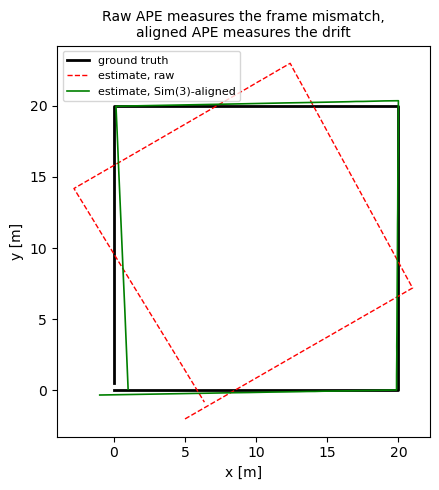

In [4]:
import matplotlib.pyplot as plt
s, R, t = umeyama(est, gt, with_scale=True)
aligned = s * est @ R.T + t
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(gt[:, 0], gt[:, 1], "k-", lw=2, label="ground truth")
ax.plot(est[:, 0], est[:, 1], "r--", lw=1, label="estimate, raw")
ax.plot(aligned[:, 0], aligned[:, 1], "g-", lw=1.2, label="estimate, Sim(3)-aligned")
ax.set_aspect("equal"); ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.legend(loc="upper left", fontsize=8)
ax.set_title("Raw APE measures the frame mismatch,\naligned APE measures the drift", fontsize=10)
plt.tight_layout(); plt.show()

## 5. Sub-trajectory drift — the recommended evaluation

**This is the central recommendation of Zhang & Scaramuzza (IROS 2018), and also the methodology behind the KITTI benchmark leaderboard.**

Idea: instead of one alignment and one RPE window, evaluate over **many sub-trajectories of different lengths** distributed along the trajectory.

**Algorithm**:

1. Pick a set of segment lengths $\mathcal{L} = \{L_1, L_2, \dots, L_k\}$.
   * KITTI uses $\{100, 200, 300, 400, 500, 600, 700, 800\}$ m.
   * For indoor / drone sequences, scale down (e.g., $\{2, 4, 6, 8, 10, 20\}$ m).
2. For each $L \in \mathcal{L}$, slide along the trajectory and extract every sub-trajectory whose **ground-truth path length** is approximately $L$.
3. **Align each sub-trajectory locally** at its starting pose (this is the key — no global alignment, only at the segment start).
4. Compute the end-to-end translation and rotation error for that segment.
5. **Normalize by length**:

$$
e_t(L) = \frac{\|\mathbf{t}_{end}\|}{L} \;\;[\%\,\text{or m/m}], \qquad
e_R(L) = \frac{|\angle R_{end}|}{L} \;\;[\text{deg/m or rad/m}].
$$

6. Report the **distribution** (median, RMSE, percentiles) of $e_t(L)$ and $e_R(L)$ for each $L$, typically as a boxplot vs. distance.

**Why this is better**:

* **Normalized by path length** → numbers are directly comparable across sequences and datasets.
* **Reveals the scale at which drift occurs**: a system can have low error at 100 m and high error at 800 m (slow drift accumulation). A single APE number hides this completely.
* **Robust statistics** (median, IQR over many segments) reduce the influence of single bad excursions.

This is exactly what **KITTI's leaderboard** reports as $t_{rel}$ (% translation error) and $r_{rel}$ (deg/100 m).


In [5]:
# Sub-trajectory drift: segments of GT length L, aligned only at their start
# pose, end-point error normalised by L (KITTI's t_rel). Two estimators:
#   A = the running example (dominated by the 10% scale error)
#   B = perfect frame, but a random-walk drift of 5 cm per step
rw = np.cumsum(rng.normal(0, 0.05, (N, 3)) * [1, 1, 0], axis=0)
est_B = gt + rw

step = 0.5
def subtraj_drift(P, RP, Q, RQ, L):
    n = int(round(L / step)); errs = []
    for i in range(0, len(P) - n, 5):
        d_gt  = RP[i].T @ (P[i + n] - P[i])
        d_est = RQ[i].T @ (Q[i + n] - Q[i])
        errs.append(100 * np.linalg.norm(d_gt - d_est) / L)     # [%]
    return np.median(errs)

print("  L      A: scale-biased   B: random-walk")
for L in [2, 5, 10, 20, 40]:
    a = subtraj_drift(gt, R_gt, est,   R_est, L)
    b = subtraj_drift(gt, R_gt, est_B, R_gt,  L)
    print(f"{L:4.0f} m   {a:10.1f} %        {b:8.1f} %")

print("\nA single APE number would hide this: A sits near its 10% scale bias at")
print("every length (dipping a little once segments span the loop's corners),")
print("while B's percentage falls steadily with L -- a random walk averages out")
print("over distance. The drift-vs-length curve separates the two failure modes.")

  L      A: scale-biased   B: random-walk
   2 m         10.3 %             5.2 %
   5 m         10.2 %             3.5 %
  10 m         10.1 %             2.7 %
  20 m          8.9 %             2.2 %
  40 m          7.3 %             2.0 %

A single APE number would hide this: A sits near its 10% scale bias at
every length (dipping a little once segments span the loop's corners),
while B's percentage falls steadily with L -- a random walk averages out
over distance. The drift-vs-length curve separates the two failure modes.


## 6. Which statistics to report

Zhang & Scaramuzza recommend reporting **more than just the mean / RMSE**:

| Statistic                  | Why it matters                                                                            |
| -------------------------- | ----------------------------------------------------------------------------------------- |
| **RMSE**                   | Standard, penalizes outliers — but is itself outlier-sensitive.                           |
| **Median**                 | Robust to a small number of bad frames.                                                   |
| **25th / 75th percentile (IQR)** | Shape of the error distribution.                                                    |
| **Max**                    | Worst-case behavior; matters when failures are unacceptable (e.g., autonomous driving).   |

For **sub-trajectory drift**, a **boxplot of error vs. segment length** is the most informative single visualization. For **APE**, both the **trajectory plot** (XY, optionally XZ) overlaid with ground truth and the **error-vs-time curve** should be shown.

When comparing systems, *always* state:

1. The **alignment used** — Sim(3) / SE(3) / posyaw / yaw-only.
2. The **timestamp matching method** — nearest-neighbor in time, max time delta.
3. **Which frames are excluded** — initialization frames, lost-track regions, the first N frames used only for alignment.
4. Whether the trajectory was **trimmed** to match GT length.

Tiny differences in these conventions cause large differences in the headline number.


In [6]:
# Why report more than the mean: 200 frames at 5 cm error, ONE bad excursion.
errors = np.full(200, 0.05); errors[100] = 2.0
print(f"RMSE   = {np.sqrt(np.mean(errors**2)):.3f} m   <- dominated by 1 frame in 200")
print(f"mean   = {errors.mean():.3f} m")
print(f"median = {np.median(errors):.3f} m   <- robust: the typical frame")
print(f"max    = {errors.max():.3f} m   <- the worst case, report it too")

RMSE   = 0.150 m   <- dominated by 1 frame in 200
mean   = 0.060 m
median = 0.050 m   <- robust: the typical frame
max    = 2.000 m   <- the worst case, report it too


## 7. Tools — `evo` and `rpg_trajectory_evaluation`

In practice you almost never compute these by hand. Three standard toolboxes:

---

### 7.1 `evo` (Michael Grupp) — [github.com/MichaelGrupp/evo](https://github.com/MichaelGrupp/evo)

The most popular general-purpose tool; supports KITTI, TUM, EuRoC, ROS bag, and ROS2 formats.

```bash
pip install evo --upgrade

# Absolute Pose Error, Sim(3) alignment, KITTI format
evo_ape kitti gt.txt est.txt -va -s --plot --plot_mode xz --save_results ape.zip

# Relative Pose Error with 100 m windows
evo_rpe kitti gt.txt est.txt -va -s --delta 100 --delta_unit m --plot

# Trajectory visualization with ground-truth reference
evo_traj kitti est.txt --ref=gt.txt -p --plot_mode=xyz

# TUM format with associate-by-timestamp
evo_ape tum gt.txt est.txt -va -as --plot      # -a SE(3), -as Sim(3)
```

Key flags:

* `-a` SE(3) alignment (rotation + translation, no scale); `-s` corrects only the scale; `-a -s` (short: `-as`) is full Sim(3).
* `--align_origin` aligns only the first pose. **posyaw / yaw-only alignment is not implemented in evo** — for the VIO-correct alignment use `rpg_trajectory_evaluation` (`align_type: posyaw`).
* `--n_to_align N` use only the first N poses for alignment (the rest are evaluated unaligned).
* `--save_results out.zip` produces a pickleable result you can re-plot with `evo_res out.zip --use_filenames -p`.

---

### 7.2 `rpg_trajectory_evaluation` (Zhang & Scaramuzza) — [github.com/uzh-rpg/rpg_trajectory_evaluation](https://github.com/uzh-rpg/rpg_trajectory_evaluation)

The toolbox that accompanies the **IROS 2018 paper**. Where `evo` is the "Swiss Army knife", this is the **paper-ready batch-evaluation** tool — it's how you'd typically generate the comparison tables and boxplots that appear in VO/SLAM publications.

**Two entry points**:

* `analyze_trajectory_single.py` — single algorithm on a single sequence.
* `analyze_trajectories.py` — **batch mode**: a matrix of algorithms × sequences, with multiple runs per (algo, seq) for variance reporting. Produces:
  * Per-dataset trajectory overlays.
  * **Sub-trajectory drift boxplots** across algorithms (the §5 methodology).
  * Per-algorithm RMSE boxplots across datasets.
  * **LaTeX tables** (mean / median / min / max / std) ready to paste into a paper.

**Input file format** (per trajectory):

```text
# stamped_groundtruth.txt  AND  stamped_traj_estimate.txt
# columns: timestamp tx ty tz qx qy qz qw   (space-separated)
0.000000  0.0000  0.0000  0.0000   0.0000  0.0000  0.0000  1.0000
0.050000  0.0123  0.0001 -0.0004   0.0000  0.0000  0.0021  1.0000
...
```

**`eval_cfg.yaml`** (per-trajectory configuration):

```yaml
align_type: sim3                # sim3 | se3 | posyaw | none
align_num_frames: -1            # -1 = use all, else first N
```

**Typical workflow**:

```bash
git clone https://github.com/uzh-rpg/rpg_trajectory_evaluation
cd rpg_trajectory_evaluation
python scripts/analyze_trajectory_single.py /path/to/results_dir
# or batch:
python scripts/analyze_trajectories.py analyze_trajectories_config/euroc_vio.yaml \
    --results_dir=/path/to/results --output_dir=/path/to/output
```

**Use this toolbox when** you want to (a) match the exact methodology of the Zhang & Scaramuzza tutorial, (b) compare several algorithms across several datasets in one shot, or (c) generate the paper-ready boxplots and LaTeX tables. For everyday one-off checks, `evo` is faster to reach for.

---

### 7.3 TUM RGB-D `evaluate_ate.py` / `evaluate_rpe.py`

The original scripts from Sturm et al. Simpler than `evo`, but still in wide use for TUM RGB-D papers.


## 8. Reporting recipe for a new VO/SLAM method

A minimal, defensible reporting recipe:

1. **Per sequence**: APE-trans RMSE + APE-trans median, with **explicit alignment** stated (e.g., "Sim(3), Umeyama"). Include rotation APE if rotation accuracy is a claim.
2. **Aggregated across the dataset**: KITTI-style $t_{rel}$ (%) and $r_{rel}$ (deg/100 m), computed on the standard segment lengths for that dataset.
3. **A trajectory plot** with ground truth overlaid for at least one representative sequence.
4. **A boxplot of drift vs. segment length** (the sub-trajectory analysis of §5) for at least one sequence — this is what reveals whether the gain comes from better local accuracy or better global consistency.
5. **Failure cases**: number of times tracking was lost; how those frames are treated in the statistics.
6. **The exact `evo` or `rpg_trajectory_evaluation` command** used. Reproducibility is cheap; not reporting it is suspicious.

Numbers without these qualifiers are not meaningful for cross-paper comparison.


## 9. Parallax — and why forward driving is the worst case

This and the next two sections cover **the diagnostic side**: not "how do I score a trajectory", but "why did the trajectory go wrong in the first place." All three failure modes show up cleanly in the alignment + APE/RPE analysis from §1–§7, and knowing which one fired tells you whether the fix is in the estimator, the sensor suite, or the trajectory itself.

The short version: **a monocular camera estimates depth from how things move across the image when the camera itself moves.** Stuff near you swings across the image fast; stuff far away barely moves. The *difference* between those motion rates is parallax, and it's the only information a single 2D image gives you about 3D depth.

Stationary observer, near + far points: the near one *appears* to move more relative to the far one. Same idea for a moving observer.

### 9.1 Why driving forward kills it

The bad case isn't *distance* per se — it's that the camera moves **along its own optical axis** (the line the camera is pointing).

Imagine driving toward a brick wall:

- The brick **directly in front** of you (on the optical axis) just gets *bigger* as you approach. It doesn't slide sideways in the image; it expands radially. **Zero parallax.**
- A brick **off to one side** does move across the image — but the motion is along a radial line outward from the image centre. The amount of motion depends on how close the brick is *and* how far off-axis it is.
- A brick **at the edge of the image** (90° off-axis) gives the maximum parallax, just like a sideways camera move would.

Mathematically, if you're at distance $D$ from a point, and you move forward by $\Delta d$, the **on-axis** point doesn't shift at all — it just scales. The **off-axis** point at angle $\theta$ shifts by roughly $(\Delta d \cdot \sin\theta) / D$ in image angle. Plug in $\theta = 0$ (dead ahead) and you get zero, regardless of $D$. That's the blind spot.

### 9.2 Tunnel / corridor geometry makes it worse

If the platform is in a tight corridor:

- Forward motion is along the camera's optical axis.
- The corridor walls are within a few metres of the camera.
- Ceiling, floor, and side walls occupy most of the FOV — so most of what the camera sees is close to "dead ahead."
- Self-similar texture (rock, brick, hex lattice) compounds the problem because the feature tracker can latch onto identical-looking neighbouring patches.

The result: VIO can correctly track *which* features are moving, but it can't pin down *how fast* the camera is actually moving in metres, because every consistent (velocity, depth) pair produces the same image motion.

### 9.3 Quick numerical example

Camera at origin looking along +X. Two features:

| Feature | Position (X, Y, Z) | Before move | After camera moves +1 m in X | Image shift |
|---|---|---|---|---|
| Dead ahead, 10 m | (10, 0, 0) | centre | centre | **0** |
| Dead ahead, 5 m  | ( 5, 0, 0) | centre | centre | **0** |
| 2 m to the side, 10 m ahead | (10, 2, 0) | 11.3° off-axis | 12.5° off-axis | 1.2° |
| 2 m to the side, 5 m ahead  | ( 5, 2, 0) | 21.8° off-axis | 26.6° off-axis | 4.8° |

The first two rows have **identical image motion** despite being at different depths. From a single mono camera, you can't tell which is which.

### 9.4 What fixes it

Three things, in order of how much they help:

1. **Sideways motion** (translation perpendicular to the optical axis). A pure sideways move turns every point into row 4 of the table above — strong parallax, strong depth signal. Rotation alone doesn't help (it changes pixel positions without changing depth), but a yaw + small forward velocity (a figure-8) gives continuous sideways translation.
2. **Stereo cameras.** With a baseline of, say, 10 cm between two cameras, you get depth-from-disparity at *every* frame — no motion required. Scale is recoverable from the first frame onward. This is the real fix for forward-driving scale loss.
3. **Depth from another sensor** (RGBD camera, LiDAR). Feeds depth directly into a depth-aware VIO. LIO does this implicitly with LiDAR scan registration — see [`VIO_DIAGNOSTIC_GUIDE.md §3`](../../vio_benchmark/docs/VIO_DIAGNOSTIC_GUIDE.md#3--why-lio-survives-bad-imu-data-and-vio-doesnt) for the structural reason LIO is also robust to bad IMU on top of this.


## 10. Mono VIO has unobservable yaw

It's not a config bug; it's a fundamental property of IMU-only static init:

- **Gravity** (a vertical vector) constrains pitch and roll. The estimator gets these right at init — that's why the trajectory stays close to z=0 (with some drift) instead of pitching into the ground.
- **Yaw** is rotation *around* the gravity axis. Gravity carries zero information about it. The IMU at rest produces the same gyro and accel readings regardless of which way the platform is facing in the world.
- The static-init code has to pick *some* yaw value to bootstrap. Without an external heading reference, it picks based on the first IMU readings + the propagated state — effectively random with respect to the world.

Symptom: trajectory looks mirrored, rotated, or pointing in the opposite direction when overlaid on GT in the world frame. Aligned APE (`-a` or `-as`) is fine because Umeyama removes the rotation; raw APE is huge.

### 10.1 What anchors yaw — and what doesn't

Only an **external heading reference** makes global yaw observable:

1. **Magnetometer fusion** — the Earth's magnetic field gives a heading reference. Most filter-based VIOs don't support it directly, but a downstream `robot_localization`-style EKF can fuse `/imu` + `/magnetometer` + `/<estimator>/odometry` and produce a yaw-anchored estimate.
2. **GNSS heading** — dual-antenna heading, or course-over-ground once the platform is moving outdoors.
3. **Known-heading prior** — if the platform always spawns facing a known direction (e.g. world +X), feeding "yaw = 0" as an init constraint nails the yaw deterministically. Usually requires a small patch to the estimator's init code.

Two popular "fixes" that do **not** anchor yaw:

* **Stereo** — the baseline makes *scale* observable from the first frame and improves robustness, but yaw is rotation about gravity and no camera pair observes it. A stereo VIO without a heading sensor has exactly the same arbitrary global yaw (see the conclusion below).
* **Loop closure** — revisiting a place enforces *internal* consistency and removes accumulated yaw **drift**, but the loop constraint is relative, not global: the whole (now self-consistent) map is still arbitrarily rotated w.r.t. the world. ORB-SLAM3 and Kimera-VIO close loops; OpenVINS' MSCKF publishes `/ov_msckf/loop_*` topics for an external loop-closure module but performs none itself.

### 10.2 Aside: ROVIO on a drone didn't have "arbitrary yaw" — why?

If you've seen a colleague run ROVIO (or any mono VIO) on a drone with **6-axis IMUs** (no magnetometer) and **two IMUs mounted in opposite orientations** for bias cancellation, and never observed the "trajectory points in the opposite direction" failure described above — three things explain that, none of which is the IMU layout:

1. **They were comparing ROVIO to ROVIO.** With no ground truth in the field, you can't *see* the arbitrary yaw offset — the estimator's trail is in its own internal world frame, and as long as motion is consistent within that frame, everything "looks right." You'd see the 180° flip on a benchmark rig with GT and raw $\|VIO - GT\|$. The drone almost certainly had the same offset, invisible.
2. **Drone motion is parallax-rich.** Constant rotation + translation in 3D means the camera-update loop pins yaw to *some* consistent value within seconds of takeoff, even though that value is arbitrary relative to north. Once pinned, it stays.
3. **Two opposing IMUs cancel bias drift.** Accelerometer/gyro biases of two units roughly cancel when averaged. That stops the wrong-yaw decision from *compounding* over time — whatever yaw was chosen at init stays stable for the whole flight. **But this doesn't add a yaw observation**; it just keeps the wrong yaw from drifting further wrong.

Aligned APE on the colleague's setup, if you'd had Vicon GT, would have shown the same yaw rotation as we see in our benchmark. It just never had to be reported, so it didn't matter for navigation.

**Conclusion**: the arbitrary-yaw effect is fundamental to any mono-VIO (or stereo-VIO without heading sensor) when reported against a fixed-world ground truth. It's an *evaluation artefact*, not a flaw in the estimator. The aligned-APE numbers are the honest quality measures. The "trail goes opposite direction in RViz" view is the unavoidable cost of having ground truth.


## 11. Tracker choice — KLT vs descriptor matching

VIO/VO front-ends track features between consecutive frames. The two common choices:

| **KLT (Kanade-Lucas-Tomasi)** | **Descriptor matching (ORB, SIFT)** |
|---|---|
| Lucas-Kanade pyramidal optical flow on corner features. | Compute a binary or float descriptor per corner, brute-force or FLANN match next frame's corners against previous. |
| Very fast — image-warp + intensity SSD per patch. | Slower — descriptor compute + match per frame. |
| Patch-based: robust to mild appearance change. | Descriptor-based: robust to viewpoint + illumination change. |
| On self-similar texture (brick walls, tile floors, hex lattice), the patch optimiser can converge to a *neighbouring identical* patch — silent false correspondence. | Lowe's ratio test (`d1/d2 < 0.7`) rejects ambiguous matches automatically. |

The failure mode that distinguishes them: KLT drifts under self-similar texture or large inter-frame motion; descriptor matchers fail more cleanly by returning fewer matches but the ones they return are unambiguous.

### 11.1 When to switch

- **Default to KLT.** Cheaper, gives more matches per frame, fine in texture-rich scenes (outdoor, varied indoor).
- **Switch to ORB/descriptors** when the scene is texture-poor or highly repetitive (corridors, factory floors, large blank walls) and you see orientation jitter that the IMU can't explain.

OpenVINS exposes this as a single config flag in `estimator_config.yaml`:

```yaml
use_klt: true   # default
use_klt: false  # ORB + binary descriptor + kNN ratio
```

Trade-off: extra CPU per frame for ORB. With `num_pts: 200` it's well within budget on a modern desktop.


## 12. References

* Z. Zhang and D. Scaramuzza, *"A Tutorial on Quantitative Trajectory Evaluation for Visual(-Inertial) Odometry"*, **IROS 2018**. [[PDF]](https://rpg.ifi.uzh.ch/docs/IROS18_Zhang.pdf) · [[Toolbox]](https://github.com/uzh-rpg/rpg_trajectory_evaluation)
* J. Sturm, N. Engelhard, F. Endres, W. Burgard, D. Cremers, *"A Benchmark for the Evaluation of RGB-D SLAM Systems"*, **IROS 2012**. (Original ATE/RPE definitions used by the TUM RGB-D toolkit.)
* A. Geiger, P. Lenz, R. Urtasun, *"Are we ready for autonomous driving? The KITTI vision benchmark suite"*, **CVPR 2012**. (Origin of the sub-trajectory drift evaluation style.)
* S. Umeyama, *"Least-squares estimation of transformation parameters between two point patterns"*, **IEEE TPAMI 1991**. (Closed-form Sim(3) alignment.)
* M. Grupp, *"evo: Python package for the evaluation of odometry and SLAM"*, [github.com/MichaelGrupp/evo](https://github.com/MichaelGrupp/evo).
